In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:90% ! important;}
div.cell.code_cell.rendered{width:100%}
div.input_prompt{padding:0px}
div.CodeMirror {font-family:Consolas ; font-size:12pt;}
div.text_cell_render.rendered_html {font-size:12pt;}
div.output {font-size:12pt; font-weight:bold}
div.input {font-family:Consolas ; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper {padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:12px;}
</style>
"""))

# red wine 품질 등급 예측

```
1. 데이터셋 확보 & 전처리
    독립변수와 타겟변수 분리 -> 독립변수 스케일조정(StandardScaler) 
    -> 타겟변수 원핫인코딩(get_dummies)
2. 모델 구성(입력11, 출력?)
3. 모델학습과정 설정(다중분류로 설정)
4. 모델 학습(callbacks이용)
5. 모델 평가 - 그래프, 평가(테스트셋), 교차표/혼동행렬
6. 모델 저장/ 사용
```

In [2]:
import numpy as np
import pandas as pd # read_csv, get_dummies, crosstab
from sklearn.preprocessing import StandardScaler # , MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential, save_model, load_model
from tensorflow.keras.layers import Input, Dense, Dropout, LeakyReLU
from tensorflow.keras import metrics
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, Callback
import matplotlib.pyplot as plt

## 1. 데이터셋 확보 & 전처리
```
    독립변수와 타겟변수 분리 -> 독립변수 스케일조정(StandardScaler) 
    -> 타겟변수 원핫인코딩(get_dummies)
    
    Fixed acidity (고정 산도): 주로 타르타르산(tartaric acid)의 양.
    Volatile acidity (휘발성 산도): 주로 아세트산(acetic acid)의 양으로, 높을수록 불쾌한 식초 맛을 유발할 수 있습니다.
    Citric acid (구연산): 와인에 신선함과 풍미를 더합니다.
    Residual sugar (잔여 당분): 발효 후 남은 당분의 양.
    Chlorides (염화물): 와인 속 소금의 양.
    Free sulfur dioxide (유리 아황산가스): 미생물 성장과 산화를 방지하는 역할을 합니다.
    Total sulfur dioxide (총 아황산가스): 유리 및 결합 형태의 아황산가스 총량.
    Density (밀도): 당도가 높을수록 밀도가 높아지는 경향이 있습니다.
    pH: 산도 수준을 나타냅니다.
    Sulphates (황산염): SO2 수준에 기여하는 와인 첨가물입니다.
    Alcohol (알코올): 와인 속 알코올 함량.
    Quality (품질): 0(매우 나쁨)에서 10(매우 우수) 사이의 전문가 평가 점수 (실제 데이터셋의 범위는 3~8).
```

In [3]:
# 데이터 읽어오기
# np.loadtxt('data/winequality-red.csv', delimiter=';', skiprows=1)
# np.genfromtxt('data/winequality-red.csv', delimiter=';', skip_header=1)
redwine = pd.read_csv('./data/winequality-red.csv', sep=';')
redwine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [4]:
# 타겟변수의 균형
redwine['quality'].value_counts()

5    681
6    638
7    199
4     53
8     18
3     10
Name: quality, dtype: int64

In [5]:
# 독립변수, 타겟변수 분리
X_redwine = redwine.iloc[:,:-1].values # to_numpy와 유사, numpy배열로
y_redwine = redwine.iloc[:,-1] # 3,4,5,6,7,8
X_redwine.shape, y_redwine.shape

((1599, 11), (1599,))

In [6]:
# 독립변수 x의 스케일 조정
scaler = StandardScaler()
scaler.fit(X_redwine)
scaled_X_redwine = scaler.transform(X_redwine)
# 다중분류를 위한 타겟변수의 원핫인코딩 -> numpy 배열로 변환
Y_redwine = pd.get_dummies(y_redwine).to_numpy()

In [9]:
print('원데이터\t원핫인코딩')
# 원핫인코딩한 0번째 인덱스가 3등급(get_dummies()사용)
np.column_stack([y_redwine[3:5], Y_redwine[3:5]])

원데이터	원핫인코딩


array([[6, 0, 0, 0, 1, 0, 0],
       [5, 0, 0, 1, 0, 0, 0]], dtype=int64)

In [7]:
# 독립변수      &        타겟변수
scaled_X_redwine.shape, Y_redwine.shape

((1599, 11), (1599, 6))

In [10]:
# 훈련셋과 테스트셋 분리(층화추출)
X_train, X_test, Y_train, Y_test = train_test_split(scaled_X_redwine,
                                                   Y_redwine,
                                                   #test_size=0.3,
                                                   train_size=0.7,
                                                   stratify=Y_redwine, # 층화
                                                   random_state=12)
X_train.shape, Y_train.shape, X_test.shape, Y_test.shape

((1119, 11), (1119, 6), (480, 11), (480, 6))

In [14]:
np.c_[pd.Series(Y_redwine.argmax(axis=1)).value_counts(normalize=True),
    pd.Series(Y_test.argmax(axis=1)).value_counts(normalize=True),
    pd.Series(Y_train.argmax(axis=1)).value_counts(normalize=True)]

array([[0.42589118, 0.425     , 0.42627346],
       [0.39899937, 0.4       , 0.39857015],
       [0.12445278, 0.125     , 0.12421805],
       [0.03314572, 0.03333333, 0.03306524],
       [0.01125704, 0.01041667, 0.01161752],
       [0.00625391, 0.00625   , 0.00625559]])

## 2. 모델 구성(입력11, 출력 6) 

In [15]:
model = Sequential()
model.add(Input(11))
model.add(Dense(units=50, activation='relu'))
model.add(Dense(units=50, activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(units=30, activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(units=6, activation='softmax'))
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 50)                600       
                                                                 
 dense_1 (Dense)             (None, 50)                2550      
                                                                 
 dropout (Dropout)           (None, 50)                0         
                                                                 
 dense_2 (Dense)             (None, 30)                1530      
                                                                 
 dropout_1 (Dropout)         (None, 30)                0         
                                                                 
 dense_3 (Dense)             (None, 6)                 186       
                                                                 
Total params: 4,866
Trainable params: 4,866
Non-trainabl

## 3. 모델 학습과정 설정(다중분류에 맞는 설정)
## 4. 학습시키기(callbacks 이용)

In [22]:
%%time
model.compile(loss='categorical_crossentropy', # sparse_categorical_crossentropy(원핫인코딩 자동으로)
              optimizer='adam',
              metrics=['accuracy'])

class CustomHistory(Callback): # on_epoch_end()함수가 epoch수행후 자동 호출 
    def __init__(self):
        self.epoch = 0
    def on_epoch_end(self, batch, logs={}):
        self.epoch += 1
        if (self.epoch % 5 == 0) | (self.epoch == 1):
            print('{}번째 loss:{:}, acc{:.4f}, val_loss{:.4f}, val_acc{:.4f}'.format(self.epoch, 
                                                                                      logs.get('loss'), 
                                                                                      logs.get('accuracy'), 
                                                                                      logs.get('val_loss'),
                                                                                      logs.get('val_accuracy')
                                                                                     ))
model_save_folder='./model'
import os
if not os.path.exists(model_save_folder): # 폴더가 없으면 폴더 생성
    os.mkdir(model_save_folder)
file = model_save_folder + 'wine-{epoch:03d}-loss{val_loss:.4f}-acc{val_accuracy:.4f}.h5'
customHistory = CustomHistory()
checkpoint = ModelCheckpoint(
                    filepath=file,
                    monitor = 'val_accuracy', # 모니터링지표 : loss, val_loss(기본값), accuracy, val_accuracy
                    save_best_only= True, # 모니터링 지표가 개선될 경우만 저장
                    mode='max',
                    varbose=0) # 로그 출력여부
earlyStopping = EarlyStopping(monitor='val_loss', patience=30)
# 학습
hist = model.fit(X_train, Y_train, epochs=200, batch_size=200, 
                validation_split=0.2, # 학습셋의 20%는 검증셋
                verbose=0, # 로그출력x
                callbacks=[earlyStopping, customHistory, checkpoint])

1번째 loss:1.5202170610427856, acc0.4592, val_loss1.5097, val_acc0.3393
5번째 loss:1.2305593490600586, acc0.4961, val_loss1.3070, val_acc0.4509
10번째 loss:1.0707019567489624, acc0.5777, val_loss1.1984, val_acc0.5134
15번째 loss:1.019926905632019, acc0.5754, val_loss1.1038, val_acc0.5268
20번째 loss:0.9619110822677612, acc0.6045, val_loss1.0692, val_acc0.5268
25번째 loss:0.935473620891571, acc0.6112, val_loss1.0466, val_acc0.5357
30번째 loss:0.9087255001068115, acc0.6067, val_loss1.0309, val_acc0.5402
35번째 loss:0.8865684866905212, acc0.6268, val_loss1.0351, val_acc0.5714
40번째 loss:0.8849554657936096, acc0.6279, val_loss1.0185, val_acc0.5670
45번째 loss:0.8597041964530945, acc0.6291, val_loss1.0178, val_acc0.5804
50번째 loss:0.8483561873435974, acc0.6525, val_loss1.0153, val_acc0.5848
55번째 loss:0.8320708274841309, acc0.6458, val_loss1.0169, val_acc0.5670
60번째 loss:0.8070129156112671, acc0.6626, val_loss1.0078, val_acc0.5625
65번째 loss:0.7908793091773987, acc0.6737, val_loss1.0037, val_acc0.5670
70번째 loss:

## 5. 모델 평가하기
- 학습과정 시각화, 평가(테스트셋), 교차표(혼동행렬)

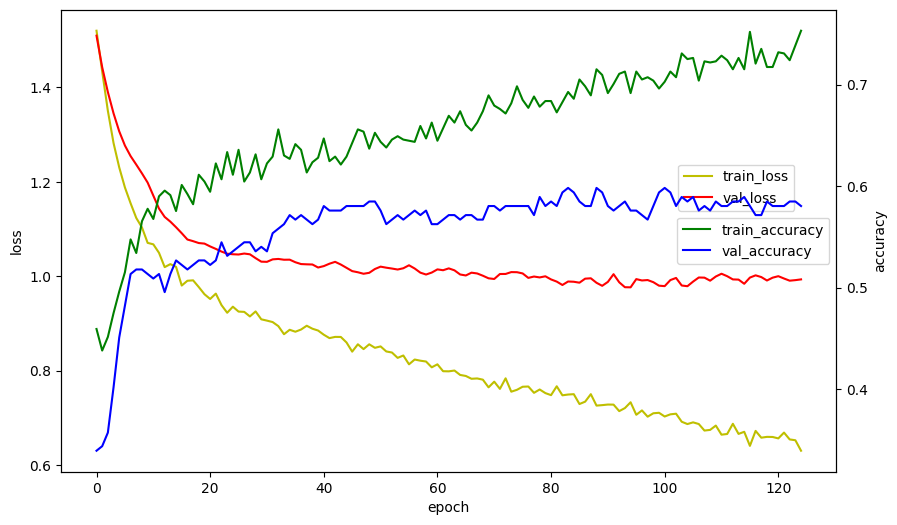

In [23]:
fig, loss_ax = plt.subplots(figsize=(10,6))
loss_ax.plot(hist.history['loss'],'y',label='train_loss')
loss_ax.plot(hist.history['val_loss'],'r',label='val_loss')
acc_ax = loss_ax.twinx() # loss_ax와 x축을 공유하는 acc_ax 생성
acc_ax.plot(hist.history['accuracy'],'g',label='train_accuracy')
acc_ax.plot(hist.history['val_accuracy'],'b',label='val_accuracy')
loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss')
acc_ax.set_ylabel('accuracy')
loss_ax.legend(bbox_to_anchor=(0.955,0.68))
acc_ax.legend(loc= 'center right')
plt.show()

In [28]:
# 모델 평가
loss_and_acc = model.evaluate(X_test, Y_test, batch_size=100, verbose=0)
print(f'loss :{loss_and_acc[0]}, accuracy:{loss_and_acc[1]:.4f}')

loss :0.9637098908424377, accuracy:0.6458


In [30]:
model1 = load_model('model/09wine-084-loss0.9888-acc0.5982.h5')
loss_and_acc1 = model1.evaluate(X_test,Y_test, verbose=0)
print(f'loss :{loss_and_acc1[0]}, accuracy:{loss_and_acc1[1]:.4f}')

loss :0.9545685648918152, accuracy:0.6479


In [31]:
model1.save('model/wine.h5')

In [39]:
# 교차표(실제값과 예측값)
real = Y_test.argmax(axis=1) +3
# real = np.argmax(Y_test, axis=1)
pred = model.predict(X_test).argmax(axis=1) + 3
# pred = np.argmax(model.predict(X_test,axis=1))

pd.crosstab(real, pred, rownames=['real'], colnames=['pred'])

15/15 [==============================] - 0s 710us/step


pred,5,6,7
real,,,
3,3,0,0
4,9,6,1
5,149,52,3
6,42,134,16
7,3,30,27
8,0,3,2


## 6. 모델 사용하기

In [40]:
X_redwine[0]

array([ 7.4   ,  0.7   ,  0.    ,  1.9   ,  0.076 , 11.    , 34.    ,
        0.9978,  3.51  ,  0.56  ,  9.4   ])

In [42]:
input_data = [ 7.4,  0.7,  0.,  1.9,  0.076, 11., 34.,  0.9978,  3.51,  0.56,  9.4]
scaled_data = scaler.transform([input_data])
model1.predict(scaled_data).argmax(axis=1)+3

1/1 [==============================] - 0s 29ms/step


array([5], dtype=int64)